In [22]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'



In [23]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [24]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB ARRAY IS RUNNING
plotting=True

In [25]:
#READING BACK IN
# import pickle
# dir2 = dir + f'Project_Algorithms/Domain_Profiles/'
# input_file = dir2 + f'mean_lfc_{res}_{t_res}_{Np_str}.pkl'

# with open(input_file, 'rb') as f:
#     mean_LFC = pickle.load(f)
# print(mean_LFC)

def LoadMeanLFC():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"MeanLFC_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        MeanLFC = pickle.load(f)
    return MeanLFC
MeanLFC=LoadMeanLFC()
mean_LFC=MeanLFC
print(f"Mean LFC is: {MeanLFC}\n")


def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {cloudbase}\n")

Mean LFC is: 1917.3723232782208

Minimum Cloudbase is: 1.2463867664337158



In [26]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

In [27]:
import numpy as np
import h5py
import os

def LoadProfiles(type, vars):
    global factor
    dir2 = os.path.join(dir, 'Project_Algorithms/Domain_Profiles/')
    if type == "general":
        input_file = os.path.join(dir2, f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5')
    elif type == "cloudy":
        input_file = os.path.join(dir2, f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5')
    else:
        raise ValueError("type must be either 'general' or 'cloudy'")

    with h5py.File(input_file, 'r') as f:
        for var in vars:
            globals()[f"profile_{type}_{var}"] = np.array(f[f"profile_{var}"])
            try:
                # If 'profile_{var}_squares' exists, use SE or SD function
                # Uncomment and define the appropriate function as needed:
                # globals()[f"profile_{type}_{var}_SE"] = ProfileStandardError(globals()[f"profile_{type}_{var}"], np.array(f[f"profile_{var}_squares"])); factor = 1.96
                globals()[f"profile_{type}_{var}_SE"] = ProfileStandardDeviation(globals()[f"profile_{type}_{var}"], np.array(f[f"profile_{var}_squares"])); factor=1
                pass
            except KeyError:
                # Create dummy SE array if not available
                dummy = globals()[f"profile_{type}_{var}"].copy()
                dummy[:, 0] = 0
                dummy = dummy[dummy[:, 1] > 1]
                globals()[f"profile_{type}_{var}_SE"] = dummy


In [30]:
def PlotProfiles(vars, xlabels, title):

    n_vars = len(vars)

    # Determine grid size: try to make it as square as possible
    n_cols = int(np.ceil(np.sqrt(n_vars)))
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    fig.suptitle(title)

    # Flatten axes array for easy indexing
    if n_vars == 1:
        axs = np.array([axs])  # Make it iterable even if only one axis
    else:
        axs = axs.flatten()

    for type in ["general", "cloudy"]:
        print(f'currently on type {type}')

        #LOADING VARIABLES IN
        LoadProfiles(type, vars)

        #Plotting function
        def plotting_func(out_var, axis, label, color):
            axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
            axis.grid(True)

        #TAKING THE AVERAGE OF THE STORED PROFILE
        for var in vars:
            globals()[f"out_{type}_{var}"] = ProfileMean(globals()[f"profile_{type}_{var}"])

        for var, axis, xlabel in zip(vars, axs, xlabels):
            color = 'black' if type == 'general' else 'blue'

            # converts qv and qc from kg/kg=>g/kg
            if var in ['qv', 'qc_plus_qi', 'HMC']:
                globals()[f"out_{type}_{var}"][:, 0] *= 1000
                globals()[f"profile_{type}_{var}_SE"][:, 0] *= 1000

            profile = globals()[f"out_{type}_{var}"]
            profile_SE = globals()[f"profile_{type}_{var}_SE"]
            plotting_func(profile, axis, label=type+' ', color=color)
            axis.fill_betweenx(profile[:, 1],
                               profile[:, 0] - factor*profile_SE[:, 0],
                               profile[:, 0] + factor*profile_SE[:, 0],
                               color=color, alpha=0.1)
            axis.set_ylabel('z (km)')
            axis.set_xlabel(xlabel)

            if axis == axs[1]:  # equivalent to your ax2
                axis.legend()

            if axis == axs[-1]:  # equivalent to your ax7
                apply_scientific_notation([axis])

    # MEAN CLOUD BASE
    axline_lw=1.1
    for axis in axs:
        axis.axhline(cloudbase, color='purple', linestyle='dashed', lw=axline_lw)
        axis.axhline(mean_LFC/1000, color='green', linestyle='dashed', lw=axline_lw)

    #FIXING BUOYANCY XLABELS
    ax_lst=[axs[8],axs[9],axs[10]]
    MatchAxisLimits(ax_lst,dim='x')

    #SCIENTIFIC NOTATION XLABEL
    apply_scientific_notation(ax_lst)
    
    # Hide any unused subplots
    for ax in axs[n_vars:]:
        ax.set_visible(False)

    plt.tight_layout()
    # plt.savefig(dir+f'Project_Algorithms/plots/eulerian_updraft_profiles_{res}_{t_res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)


currently on type general
currently on type cloudy


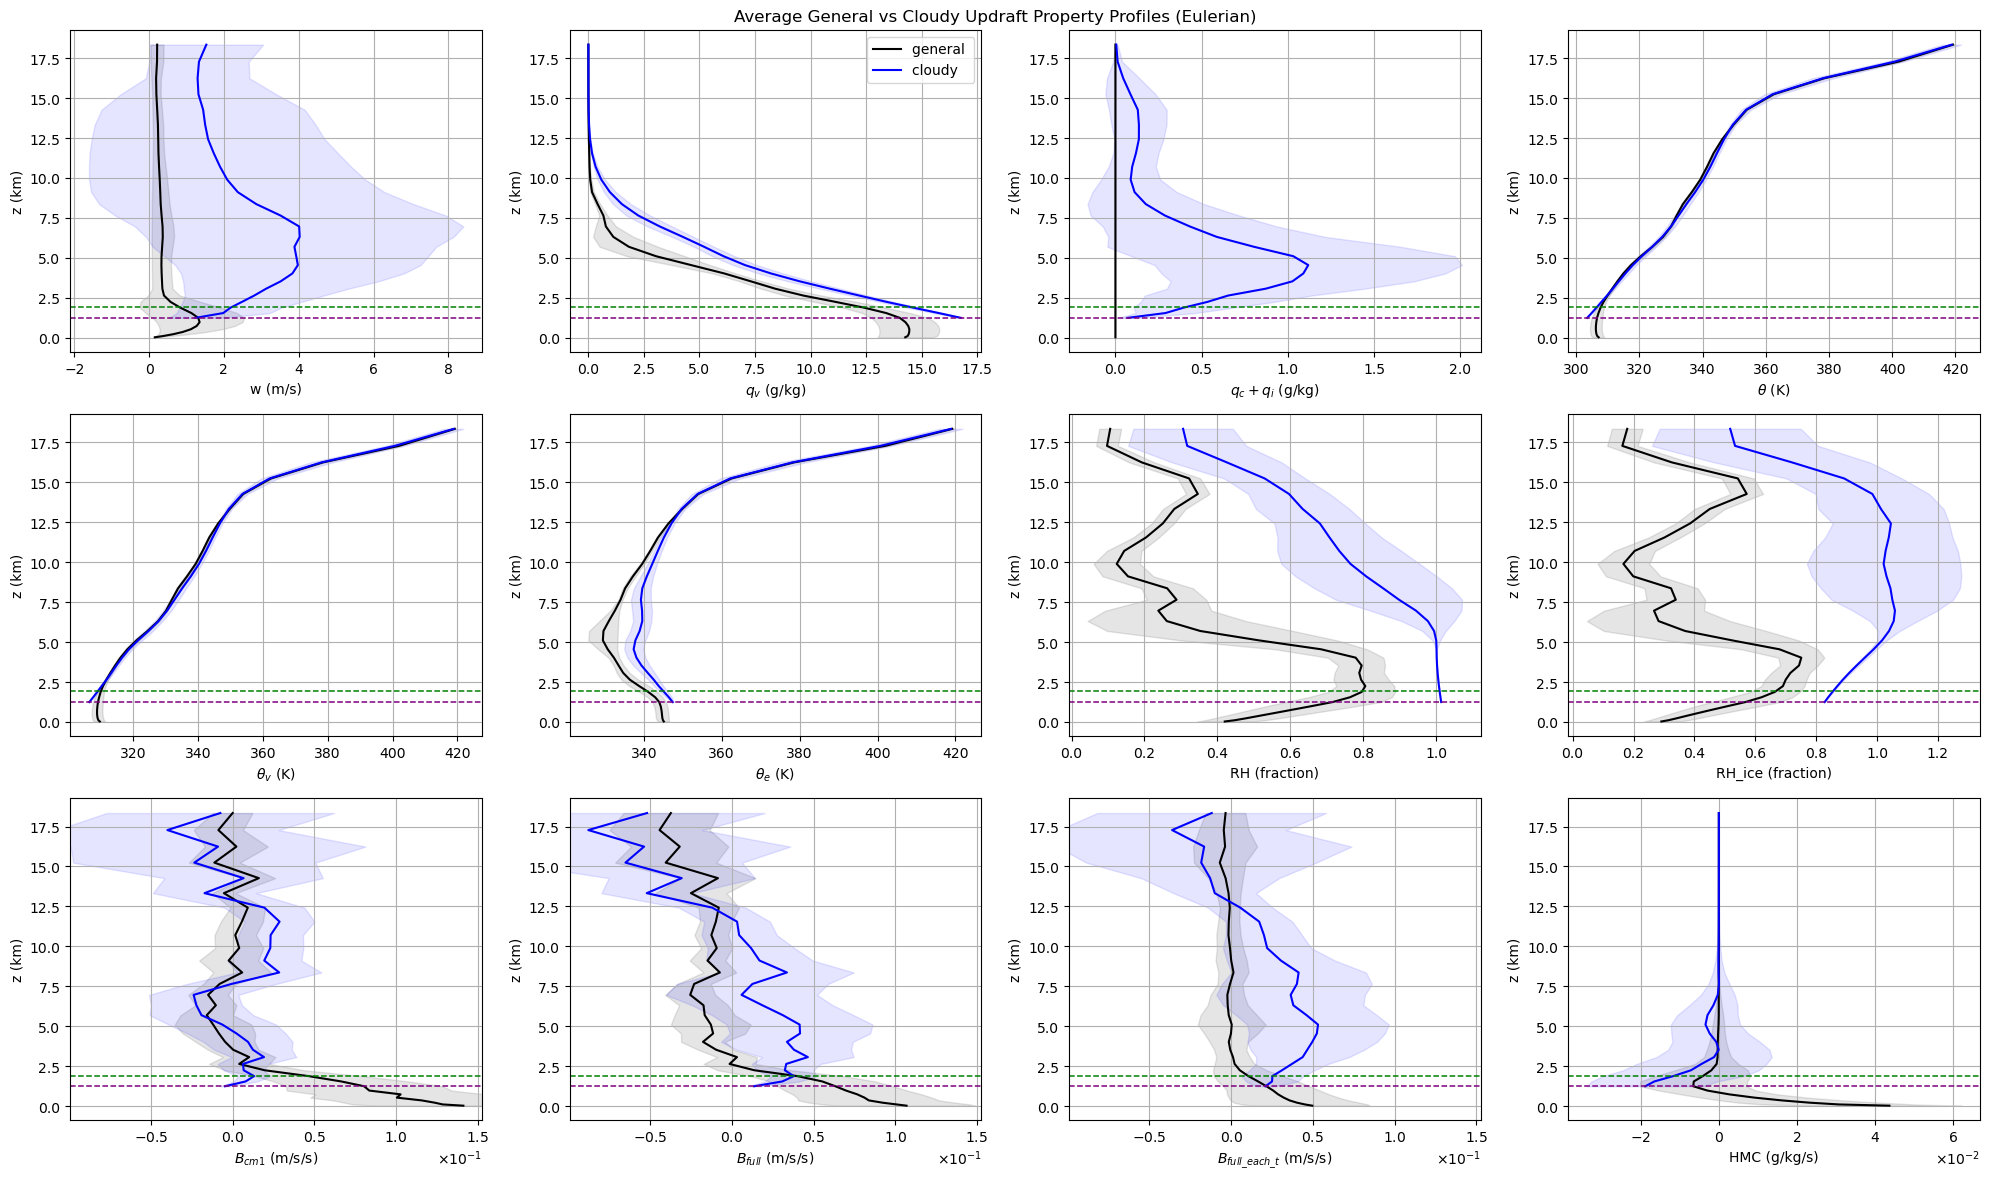

In [35]:
#RUNNING PLOTTING FUNCTION
vars=['w','qv','qc_plus_qi','th','th_v','th_e','RH','RH_ice','buoyancy_cm1','buoyancy_full','buoyancy_full_each_t','HMC'] 
xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_v$ (K)',r'$\theta_e$ (K)','RH (fraction)','RH_ice (fraction)',r'$B_{cm1}$ (m/s/s)',r'$B_{full}$ (m/s/s)', r'$B_{full\_each\_t}$ (m/s/s)', 'HMC (g/kg/s)'] 
title=f"Average General vs Cloudy Updraft Property Profiles (Eulerian)"

PlotProfiles(vars,xlabels,title)

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def averaged_profiles(profile):
    """Return average profile by normalizing by count and filtering"""
    out_var = profile[(profile[:, 1] > 1)]  # remove rows with no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T
    return out_var

def get_data(type_, var_list, dir, res, t_res, Np_str):
    """Load profiles for given type and variables from HDF5 files"""
    dir2 = dir + 'Project_Algorithms/Domain_Profiles/'
    input_file = f"{dir2}job_out/{type_}_eulerian_profiles_{res}_{t_res}_{Np_str}.h5"
    
    data_dict = {}
    with h5py.File(input_file, 'r') as f:
        for var in var_list:
            data_dict[f"profile_{var}"] = np.array(f[f"profile_{var}"])
    return data_dict

def average_difference(array1, array2):
    """Compute difference between averaged profiles where z matches"""
    out_var_one = averaged_profiles(array1)
    out_var_two = averaged_profiles(array2)

    # mask to keep matching heights
    mask_one = np.isin(out_var_one[:, 1], out_var_two[:, 1])
    mask_two = np.isin(out_var_two[:, 1], out_var_one[:, 1])

    out_var_one = out_var_one[mask_one]
    out_var_two = out_var_two[mask_two]

    diff = out_var_one[:, 0] - out_var_two[:, 0]
    zs = out_var_one[:, 1]

    out_profile = np.zeros((len(diff), 2))
    out_profile[:, 0] = diff
    out_profile[:, 1] = zs
    return out_profile

def diff_plotting(vars,xlabels,title):
    """Return cloudy minus general updraft difference plots"""
    # Setup figure and axes
    n_vars = len(vars)
    n_cols = int(np.ceil(np.sqrt(n_vars)))
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    fig.suptitle(title)

    if n_vars == 1:
        axs = np.array([axs])
    else:
        axs = axs.flatten()

    # Load data once per type to avoid repeated I/O
    data_cloudy = get_data("cloudy", vars, dir, res, t_res, Np_str)
    data_general = get_data("general", vars, dir, res, t_res, Np_str)

    for var, axis, xlabel in zip(vars, axs, xlabels):
        print(var)
        out_var_one = data_cloudy[f"profile_{var}"]
        out_var_two = data_general[f"profile_{var}"]

        # Cutoff indices where cloudy count > 10 (optional)
        cutofflow_idx = np.where(out_var_one[:, 1] > 10)[0][0]
        cutoffhigh_idx = np.where(out_var_one[:, 1] > 10)[0][-1]

        # Compute average difference profile
        out_var_diff = average_difference(out_var_one, out_var_two)

        # Convert units for some variables (kg/kg to g/kg)
        if var in ['qv', 'qc_plus_qi', 'qi', 'HMC']:
            out_var_diff[:, 0] *= 1000

        axis.plot(out_var_diff[:, 0], out_var_diff[:, 1], color='black')
        axis.axvline(0, color='black', linestyle='dashed')

        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)
        axis.grid(True)

        apply_scientific_notation([axis])

    # Hide unused axes
    for ax in axs[n_vars:]:
        ax.set_visible(False)

    #FIXING BUOYANCY XLABELS
    ax_lst=[axs[8],axs[9],axs[10]]
    MatchAxisLimits(ax_lst,dim='x')

    # MEAN CLOUD BASE
    axline_lw=1.1
    for axis in axs:
        axis.axhline(cloudbase, color='purple', linestyle='dashed', lw=axline_lw)
        axis.axhline(mean_LFC/1000, color='green', linestyle='dashed', lw=axline_lw)

    plt.tight_layout()
    # plt.savefig(dir + f'Project_Algorithms/plots/eulerian_updraft_profiles_diff_{res}_{t_res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)

w
qv
qc_plus_qi
th
th_v
th_e
RH
RH_ice
buoyancy_cm1
buoyancy_full
buoyancy_full_each_t
HMC


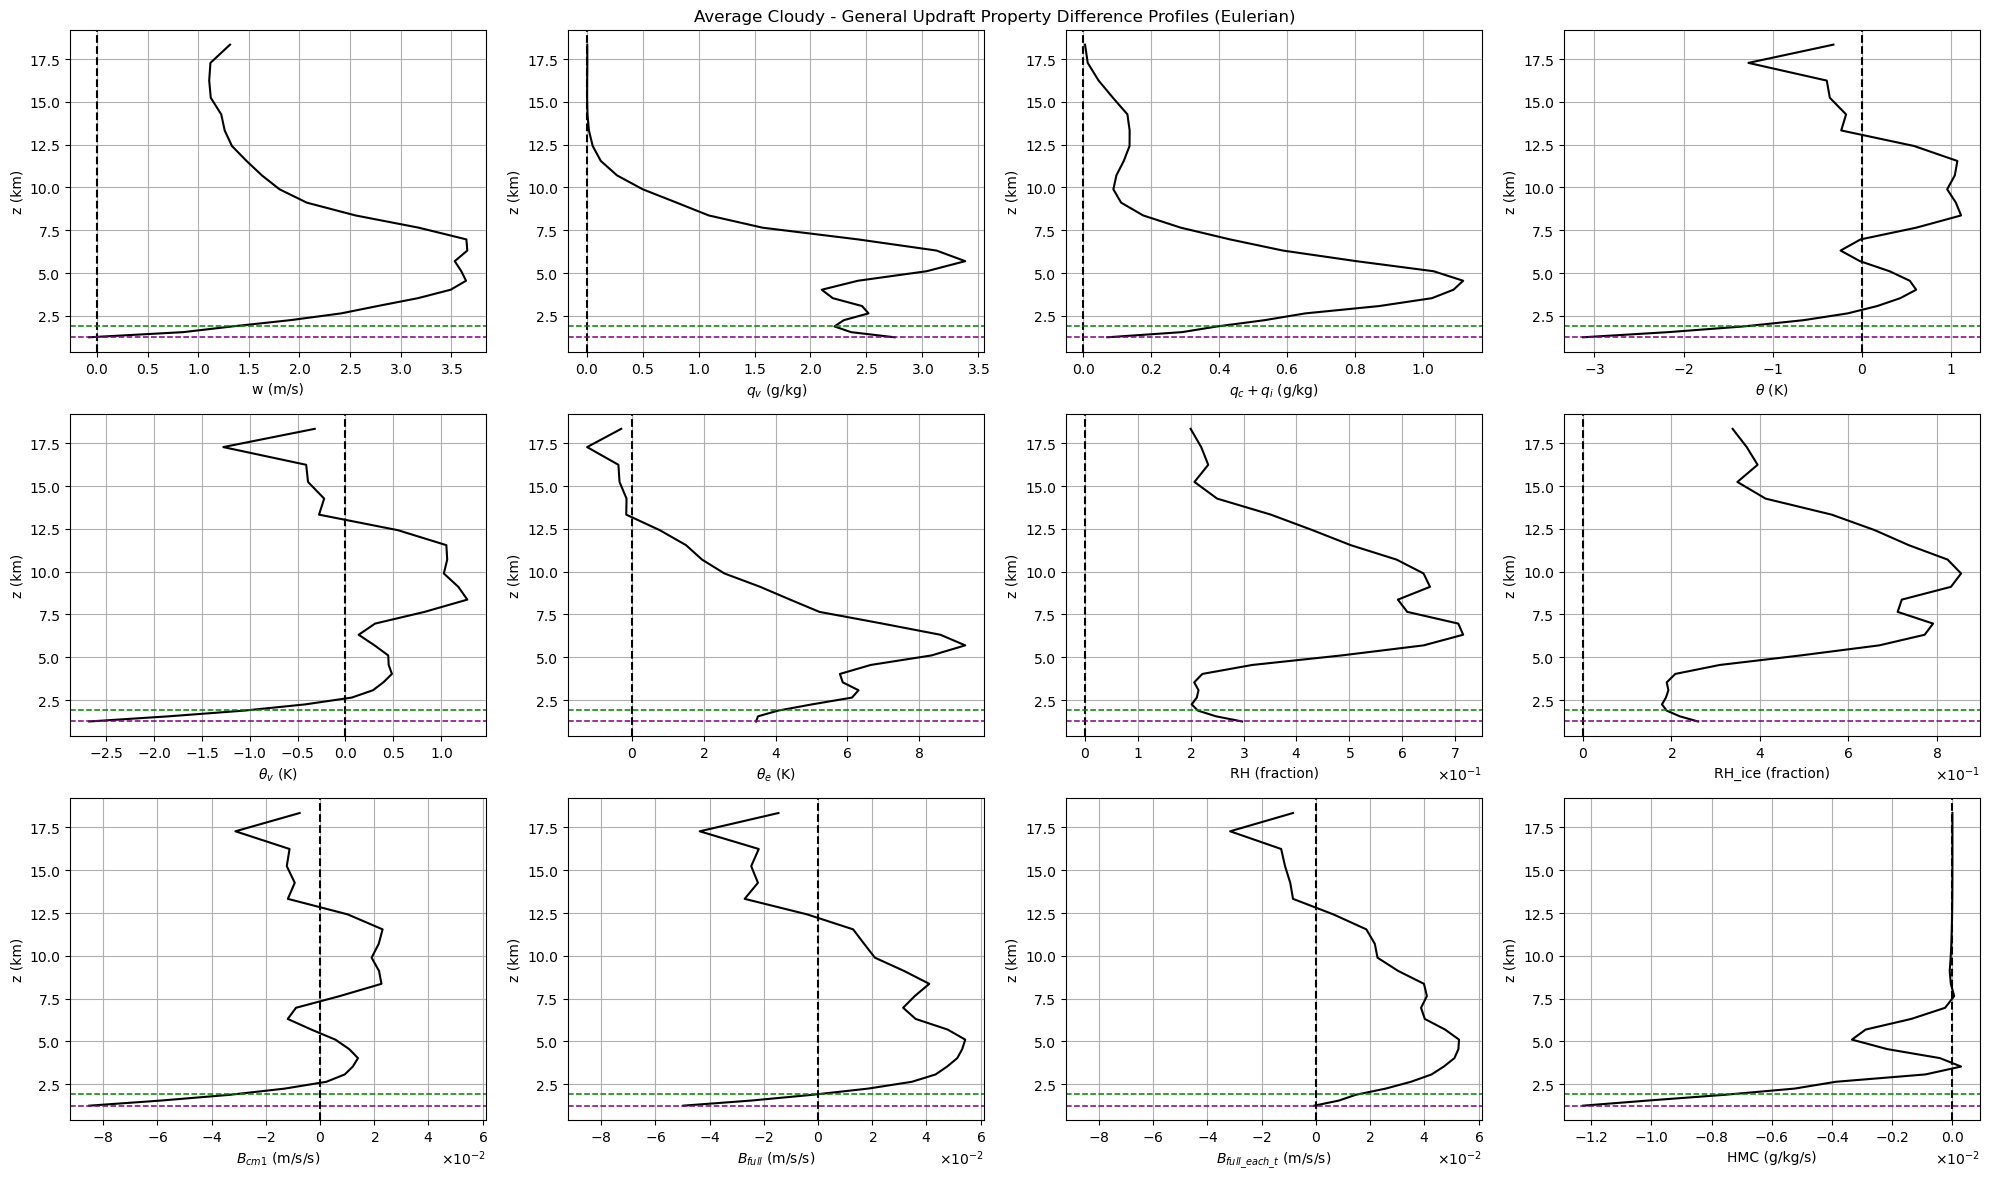

In [37]:
title=f"Average Cloudy - General Updraft Property Difference Profiles (Eulerian)"
diff_plotting(vars,xlabels,title)


In [38]:
########################################
#TESTING

In [33]:
# type="general"
# # type="cloudy"
# dir2=dir+'Project_Algorithms/Domain_Profiles/'
# if type == "general":
#     input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
# elif type == "cloudy":
#     input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 

# with h5py.File(input_file, 'r') as f:
#     profile_w = np.array(f['profile_w'])
#     profile_w_squares = np.array(f['profile_w_squares'])


# import matplotlib.gridspec as gridspec
# profile_w_SE = ProfileStandardError(profile_w, profile_w_squares)
# # profile_w_SE = ProfileStandardDeviation(profile_w, profile_w_squares)

# out1 = profile_w_SE.copy()

# out2 = ProfileMean(profile_w)
# multiple = 1

# fig = plt.figure(figsize=(12, 5))
# gs = gridspec.GridSpec(1, 2, figure=fig)

# ax1 = fig.add_subplot(gs[0, 0])
# ax1.plot(out1[:, 0], out1[:, 1])

# ax2 = fig.add_subplot(gs[0, 1])
# profile=out2.copy();profile_SE=profile_w_SE.copy();switch=1
# ax2.plot(profile[:, 0], profile[:, 1], color='blue')
# ax2.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*profile_SE[:,0]*switch, profile[:, 0] + 1.96*profile_SE[:,0], color='blue', alpha=0.1)

# plt.tight_layout()
# plt.show()

In [34]:
# #TESTING WHY DIFFERENCES IN TH AND BUOYANCY ARE SO SIMILAR

# var='buoyancy'
# types=['cloudy','general']
# one=globals()[f"{types[0]}_profile_{var}"]
# two=globals()[f"{types[1]}_profile_{var}"]

# one_mean=ProfileMean(one)
# two_mean=ProfileMean(two)
# plt.plot(one_mean[:,0],one_mean[:,1])
# plt.plot(two_mean[:,0],two_mean[:,1])

# plt.show()

# var='th'
# types=['cloudy','general']
# one=globals()[f"{types[0]}_profile_{var}"]
# two=globals()[f"{types[1]}_profile_{var}"]

# one_mean=ProfileMean(one)
# two_mean=ProfileMean(two)
# plt.plot(one_mean[:,0],one_mean[:,1])
# plt.plot(two_mean[:,0],two_mean[:,1])

# plt.show()

# var='th'
# types=['cloudy','general']
# one=globals()[f"{types[0]}_profile_{var}"]
# two=globals()[f"{types[1]}_profile_{var}"]

# out1=average_difference(one,two)
# plt.plot(out1[:,0],out1[:,1])


# plt.show()


# var='buoyancy'
# types=['cloudy','general']
# one=globals()[f"{types[0]}_profile_{var}"]
# two=globals()[f"{types[1]}_profile_{var}"]

# out2=average_difference(one,two)
# plt.plot(out2[:,0],out2[:,1])

# plt.show()

# plt.plot(out1[:,0]/out2[:,0],out1[:,1])
